In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#classification dataset load_iris
from sklearn.datasets import load_iris

In [100]:
# Data loading and preprocessing
data=load_iris()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
df.head()
# check row and colums size of dataset
df.shape
# First five rows data
df.head()
# check  null records
df.isnull().sum()

# features
X=df.drop('target',axis=1)
# target
y=df['target']

In [101]:
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
# Method 1 train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
# model=LogisticRegression()
model=DecisionTreeClassifier(random_state=42)

model.fit(X_train,y_train)
y_pred=model.predict(X_test)

# method 2 cross val score
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Average Accuracy:", scores.mean())

[0.96666667 0.96666667 0.9        0.93333333 1.        ]
Average Accuracy: 0.9533333333333334


In [102]:
# test for unseen data
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)

print("Predicted Class:", prediction[0])
print("Flower Name:", data.target_names[prediction[0]])

Predicted Class: 0
Flower Name: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [103]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(classification_report(y_test,y_pred))
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Accuracy: 1.0


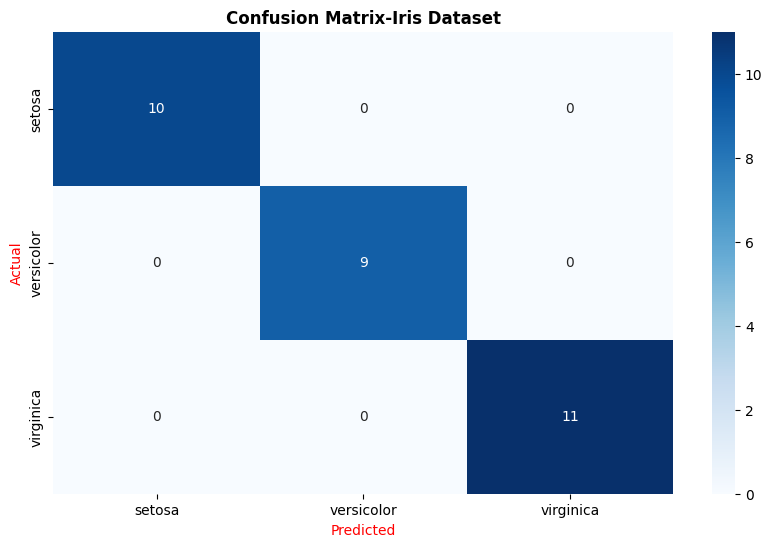

In [104]:
# confusion Tree visual representation
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d',cmap='Blues',xticklabels=data.target_names,yticklabels=data.target_names)
plt.xlabel('Predicted',color='Red')
plt.ylabel('Actual',color='Red')
plt.title('Confusion Matrix-Iris Dataset',fontweight='bold')
plt.show()
